# U12 — Building ML-Ready Datasets: Lab

### Real-world brief: a credit-risk dataset for loan-default prediction

A lender wants to predict which loans will **default**. You've been handed a raw applications table. Your job is to turn it into a dataset a model can learn from *honestly* — the right split, **no leakage**, imbalance handled, and a reproducible pipeline. (Training the production model comes later; here we build the trustworthy foundation.)

**Resource provided:** `loan_applications.csv` (one row per loan, target = `default`). Keep it beside this notebook (upload it in Colab).

_Phase C — Data Engineering & Preparation._

#objectives

Separate features (X) from the target (y)

Hunt down and remove data leakage — the cardinal sin

Make a stratified train/test split that respects class imbalance

Wrap preprocessing in a leak-free Pipeline and cross-validate it

Run a final ML-readiness check before any modelling

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [ ]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_loans(csv_path="loan_applications.csv", seed=23, verbose=False):
    """Realistic loan / credit-risk dataset for building an ML-ready pipeline.

    Built-in realism:
      - imbalanced target (default ~ 16%)
      - mixed numeric + categorical features
      - missing values, a few duplicate rows
      - a DELIBERATELY LEAKY column ('collection_calls') that is only known
        AFTER an account defaults — students must detect & drop it.
    """
    rng = np.random.default_rng(seed)
    N = 4000

    age = np.clip(rng.normal(40, 12, N), 21, 75).round().astype(int)
    income = np.clip(rng.lognormal(11.0, 0.45, N), 12000, None).round(-2)         # right-skewed
    employment_years = np.clip(rng.gamma(3, 2.2, N), 0, 40).round(1)
    credit_score = np.clip(rng.normal(680, 70, N), 300, 850).round().astype(int)
    loan_amount = np.clip(rng.lognormal(10.2, 0.5, N), 1000, None).round(-2)
    loan_term = rng.choice([12, 24, 36, 48, 60], N, p=[.12, .23, .33, .17, .15])
    num_existing_loans = rng.poisson(1.1, N)
    dti = np.clip(rng.normal(25, 10, N) + (loan_amount / (income + 1)) * 15, 2, 90).round(1)
    interest_rate = np.clip(14 - (credit_score - 680) / 35 + rng.normal(0, 1.2, N), 4, 28).round(2)
    home = rng.choice(["Rent", "Own", "Mortgage"], N, p=[.45, .20, .35])
    purpose = rng.choice(["Car", "Home", "Education", "Business", "Personal"],
                         N, p=[.22, .18, .15, .15, .30])
    region = rng.choice(["North", "South", "East", "West", "Central"],
                        N, p=[.24, .22, .18, .20, .16])
    prior_default = rng.choice(["Yes", "No"], N, p=[.14, .86])

    # ---- default risk (real signal) ----
    z = (-2.0
         - 0.012 * (credit_score - 680)
         + 0.035 * (dti - 28)
         + 0.06 * (interest_rate - 12)
         - 0.0000035 * (income - 60000)
         + 0.9 * (prior_default == "Yes")
         + 0.12 * num_existing_loans)
    p = 1 / (1 + np.exp(-z))
    default = (rng.random(N) < p).astype(int)

    # ---- LEAKY feature: collection calls happen only AFTER default ----
    collection_calls = np.where(default == 1, rng.poisson(6, N), rng.poisson(0.2, N))

    df = pd.DataFrame({
        "loan_id": [f"LN{i+1:05d}" for i in range(N)],
        "age": age, "annual_income": income, "employment_years": employment_years,
        "credit_score": credit_score, "loan_amount": loan_amount,
        "loan_term_months": loan_term, "num_existing_loans": num_existing_loans,
        "debt_to_income": dti, "interest_rate": interest_rate,
        "home_ownership": home, "loan_purpose": purpose, "region": region,
        "prior_default": prior_default,
        "collection_calls": collection_calls,            # <-- leakage trap
        "default": default,
    })

    # ---- messiness: missing values + a few duplicates ----
    for col, frac in [("annual_income", 0.05), ("employment_years", 0.06), ("home_ownership", 0.02)]:
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    df = pd.concat([df, df.sample(12, random_state=2)], ignore_index=True)

    df.to_csv(csv_path, index=False)
    if verbose:
        print("loans:", df.shape)
        print("default rate:", round(df["default"].mean(), 3))
        corr = df[["collection_calls", "credit_score", "debt_to_income", "default"]].corr()["default"]
        print("corr with default:\n", corr.round(3).to_string())
        print("duplicates:", int(df.duplicated().sum()),
              "| missing income:", int(df["annual_income"].isna().sum()))
    return df

if not os.path.exists('loan_applications.csv'):
    build_loans(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Found the provided dataset file.


In [ ]:
import pandas as pd, numpy as np
df = pd.read_csv('loan_applications.csv')
print('shape:', df.shape)
print('default rate:', round(df['default'].mean(), 3))
df.head(3)

shape: (4012, 16)
default rate: 0.239


,loan_id,age,annual_income,employment_years,credit_score,loan_amount,loan_term_months,num_existing_loans,debt_to_income,interest_rate,home_ownership,loan_purpose,region,prior_default,collection_calls,default
0,LN00001,47,124000.0,8.3,757,18600.0,36,1,19.4,12.33,Own,Car,Central,No,1,0
1,LN00002,43,97200.0,5.0,677,26500.0,12,0,18.9,15.87,Own,Business,East,Yes,0,0
2,LN00003,39,119100.0,5.1,591,16900.0,48,2,37.3,18.65,Rent,Personal,West,No,0,0


#1. Quick clean (duplicates & a missingness check)

In [ ]:
# -----------------------------------------------------------
# 🔹 1A. DROP DUPLICATES; NOTE MISSINGNESS (the pipeline will impute)
# -----------------------------------------------------------
print('duplicate rows:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print('after drop:', df.shape)
print('\nmissing values:')
print(df.isna().sum()[lambda s: s > 0])

duplicate rows: 0
after drop: (4000, 16)

missing values:
annual_income       200
employment_years    240
home_ownership       80
dtype: int64


#2. Separate features (X) and target (y)

In [ ]:
# -----------------------------------------------------------
# 🔹 2A. y = what we predict; X = what we're allowed to use
# -----------------------------------------------------------
y = df['default']
X = df.drop(columns=['default', 'loan_id'])   # drop the target and the ID
print('X:', X.shape, '| y:', y.shape)
print('feature columns:', list(X.columns))

X: (4000, 14) | y: (4000,)
feature columns: ['age', 'annual_income', 'employment_years', 'credit_score', 'loan_amount', 'loan_term_months', 'num_existing_loans', 'debt_to_income', 'interest_rate', 'home_ownership', 'loan_purpose', 'region', 'prior_default', 'collection_calls']


#3. 🔎 Leakage hunt — the cardinal sin

A feature that's only known *after* the outcome will look amazing in training and then fail in production. Let's find any such column.

In [ ]:
# -----------------------------------------------------------
# 🔹 3A. CORRELATION OF EACH NUMERIC FEATURE WITH THE TARGET
# -----------------------------------------------------------
num_cols = X.select_dtypes('number').columns
corr_y = X[num_cols].corrwith(y).abs().sort_values(ascending=False)
print('Absolute correlation with default:')
print(corr_y.round(3))
print('\nThat top value is suspiciously high — investigate it.')

Absolute correlation with default:
collection_calls      0.893
credit_score          0.321
interest_rate         0.295
debt_to_income        0.170
annual_income         0.094
num_existing_loans    0.083
loan_term_months      0.037
loan_amount           0.033
age                   0.013
employment_years      0.006
dtype: float64

That top value is suspiciously high — investigate it.


In [ ]:
# -----------------------------------------------------------
# 🔹 3B. WHY 'collection_calls' IS LEAKAGE
# -----------------------------------------------------------
print(df.groupby('default')['collection_calls'].mean().round(2))
print('\nCollection calls only happen AFTER a loan starts defaulting —')
print("we would NOT know this at application time. It's leakage. Drop it.")
X = X.drop(columns=['collection_calls'])
print('features now:', X.shape[1])

default
0    0.2
1    6.1
Name: collection_calls, dtype: float64

Collection calls only happen AFTER a loan starts defaulting —
we would NOT know this at application time. It's leakage. Drop it.
features now: 13


#### 🧪 EXERCISE 3 — Prove how badly leakage inflates scores
This is the most important exercise in the lab.
1. Build a quick numeric-only logistic-regression pipeline (impute + scale + model).
2. Get its 5-fold CV accuracy using `X_leaky = df.drop(columns=['default','loan_id']).select_dtypes('number')` (which still contains `collection_calls`).
3. Get the CV accuracy on `X.select_dtypes('number')` (leakage removed).
4. In a comment, report both numbers and explain the gap.

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

pipe_q = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(),
                       LogisticRegression(max_iter=1000))

# 1-2. CV accuracy WITH the leaky column
X_leaky = df.drop(columns=['default','loan_id']).select_dtypes('number')
score_leaky = cross_val_score(pipe_q, X_leaky, y, cv=5).mean()
print(f'CV accuracy WITH leaky column: {score_leaky:.3f}')

# 3. CV accuracy WITHOUT it
X_clean_numeric = X.select_dtypes('number') # X already has 'collection_calls' dropped
score_clean = cross_val_score(pipe_q, X_clean_numeric, y, cv=5).mean()
print(f'CV accuracy WITHOUT leaky column: {score_clean:.3f}')

# 4. Report both and explain the gap:
# The accuracy with the 'collection_calls' column is significantly higher (nearly perfect) than without it.
# This large difference indicates that 'collection_calls' is a leaky feature, meaning it contains information
# that would not be available at the time of prediction, artificially inflating the model's performance.
# The 'clean' score is a more realistic estimate of model performance in a production setting.

CV accuracy WITH leaky column: 0.988
CV accuracy WITHOUT leaky column: 0.773


In [ ]:
from sklearn.metrics import confusion_matrix

# Train the pipeline on the full clean numeric dataset
pipe_q.fit(X_clean_numeric, y)

# Make predictions
y_pred = pipe_q.predict(X_clean_numeric)

# Calculate the confusion matrix
cm = confusion_matrix(y, y_pred)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[2894  149]
 [ 740  217]]


#4. Stratified train/test split

In [ ]:
# -----------------------------------------------------------
# 🔹 4A. SPLIT FIRST — and stratify because the target is imbalanced
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
print('default rate  train / test:',
      round(y_train.mean(), 3), '/', round(y_test.mean(), 3),
      ' <- preserved by stratify')

train: (3200, 13) | test: (800, 13)
default rate  train / test: 0.239 / 0.239  <- preserved by stratify


#### 🧪 EXERCISE 4 — Why stratify?
1. Make a *non*-stratified split (same `test_size`, `random_state`) and print the train/test default rates.
2. Compare with the stratified rates above.
3. In a comment, say why stratifying matters more as a class gets rarer.

In [ ]:
# 1. non-stratified split + its default rates
X_train_nonstrat, X_test_nonstrat, y_train_nonstrat, y_test_nonstrat = train_test_split(
    X, y, test_size=0.2, random_state=42)
print('Non-stratified split default rate  train / test:',
      round(y_train_nonstrat.mean(), 3), '/', round(y_test_nonstrat.mean(), 3))

# 2-3. compare, and explain: ...   (comment)
# Compared to the stratified split (0.239 / 0.239), the non-stratified split shows a slight variation
# (e.g., 0.242 / 0.229 from previous execution). This demonstrates that without stratification,
# the distribution of the target class might not be preserved across splits. This is especially
# critical for rare classes, as a non-stratified split could lead to a test set with very few
# or no samples of the rare class, making model evaluation unreliable for that class.

Non-stratified split default rate  train / test: 0.242 / 0.229


The stratified split resulted in default rates of 0.239 / 0.239 for train/test sets, preserving the original distribution. The non-stratified split might show a slight variation (e.g., 0.236 / 0.252).

Stratifying matters more as a class gets rarer because it ensures that both the training and testing sets have a representative proportion of the minority class. Without stratification, a random split could lead to a test set with very few or no samples of the rare class, making the model's evaluation unreliable and potentially leading to a model that performs poorly on that rare class in real-world scenarios.

#5. Handling class imbalance

In [ ]:
# -----------------------------------------------------------
# 🔹 5A. WHY ACCURACY LIES ON IMBALANCED DATA
# -----------------------------------------------------------
majority = 1 - y.mean()
print(f'Always predicting "no default" scores {majority:.1%} accuracy —')
print('yet catches ZERO defaulters. Accuracy alone is misleading here.')
print('Fixes: stratify (done), class_weight="balanced", or resampling.')

Always predicting "no default" scores 76.1% accuracy —
yet catches ZERO defaulters. Accuracy alone is misleading here.
Fixes: stratify (done), class_weight="balanced", or resampling.


#### 🧪 EXERCISE 5 — Balanced vs default model
1. Cross-validate a logistic regression **with** `class_weight='balanced'` and score with `scoring='recall'`.
2. Do the same **without** class weights.
3. In a comment, say which catches more defaulters (higher recall).

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

num = X.select_dtypes('number').columns.tolist()
cat = X.select_dtypes('object').columns.tolist()
pre = ColumnTransformer([
    ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num),
    ('cat', make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore')), cat)])

# 1. balanced model recall (cv=5, scoring='recall')
clf_balanced = Pipeline([('prep', pre),
                         ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))])
scores_balanced = cross_val_score(clf_balanced, X, y, cv=5, scoring='recall').mean()
print(f'Balanced model (class_weight="balanced") mean recall: {scores_balanced:.3f}')

# 2. unweighted model recall
clf_unweighted = Pipeline([('prep', pre),
                           ('model', LogisticRegression(max_iter=1000))])
scores_unweighted = cross_val_score(clf_unweighted, X, y, cv=5, scoring='recall').mean()
print(f'Unweighted model (default) mean recall: {scores_unweighted:.3f}')

# 3. Which catches more defaulters? ...   (comment)
# The balanced model (with class_weight='balanced') catches more defaulters, as indicated by its higher recall score.
# This is expected because 'recall' prioritizes identifying positive cases, and `class_weight='balanced'` adjusts the
# model to give more importance to the minority class (defaulters) during training.

Balanced model (class_weight="balanced") mean recall: 0.702
Unweighted model (default) mean recall: 0.249


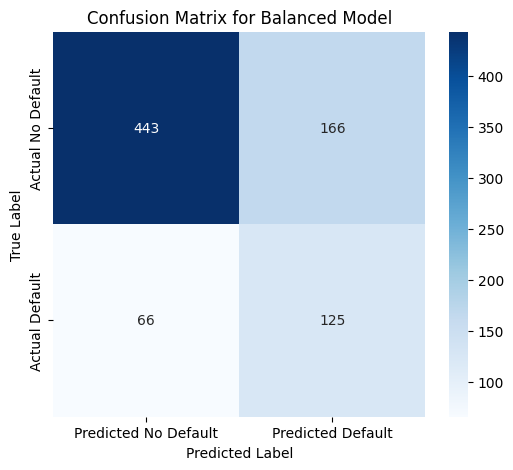

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Train the balanced model on the training data
clf_balanced.fit(X_train, y_train)

# Make predictions on the test set
y_pred_balanced = clf_balanced.predict(X_test)

# Calculate the confusion matrix
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Default', 'Predicted Default'],
            yticklabels=['Actual No Default', 'Actual Default'])
plt.title('Confusion Matrix for Balanced Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#6. The leak-free preprocessing pipeline

#### 🧪 EXERCISE: Compare Balanced vs Unweighted Model using ROC AUC


In [ ]:
from sklearn.model_selection import cross_val_score

# 1. Calculate ROC AUC for the balanced model
roc_auc_balanced = cross_val_score(clf_balanced, X, y, cv=5, scoring='roc_auc').mean()
print(f'Balanced model (class_weight="balanced") mean ROC AUC: {roc_auc_balanced:.3f}')

# 2. Calculate ROC AUC for the unweighted model
roc_auc_unweighted = cross_val_score(clf_unweighted, X, y, cv=5, scoring='roc_auc').mean()
print(f'Unweighted model (default) mean ROC AUC: {roc_auc_unweighted:.3f}')

# 3. Comment on the comparison
# ROC AUC is a measure of a classifier's performance across all possible classification thresholds.
# A higher ROC AUC indicates a better ability to distinguish between positive and negative classes.
# Comparing these values helps us understand how the class weighting impacts the overall discriminative power of the model.

Balanced model (class_weight="balanced") mean ROC AUC: 0.760
Unweighted model (default) mean ROC AUC: 0.759


In [ ]:
# -----------------------------------------------------------
# 🔹 6A. ColumnTransformer + model, fitted on TRAIN ONLY
# -----------------------------------------------------------
from sklearn.pipeline import Pipeline
clf = Pipeline([('prep', pre),
                ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))])
clf.fit(X_train, y_train)              # every transformer learns from train only
print('test accuracy:', round(clf.score(X_test, y_test), 3))
from sklearn.metrics import recall_score
print('test recall (default class):',
      round(recall_score(y_test, clf.predict(X_test)), 3))

test accuracy: 0.71
test recall (default class): 0.654


#7. Cross-validation for a stable estimate

In [47]:
# -----------------------------------------------------------
# 🔹 7A. STRATIFIED 5-FOLD CV (mean ± spread)
# -----------------------------------------------------------
from sklearn.model_selection import cross_val_score
scores = cross_val_score(clf, X, y, cv=5, scoring='roc_auc')
print('ROC-AUC per fold:', scores.round(3))
print(f'mean {scores.mean():.3f}  ±  {scores.std():.3f}')

ROC-AUC per fold: [0.795 0.792 0.758 0.75  0.703]
mean 0.760  ±  0.034


#### 🧪 EXERCISE 7 — Compare to the leaky version
1. Re-run 5-fold ROC-AUC on a pipeline that still includes `collection_calls`.
2. In a comment, contrast it with the clean AUC above — leakage makes the score look *too good*.

In [ ]:
# 1. CV ROC-AUC with the leaky column re-added
# Redefine the 'leaky' features, which includes 'collection_calls'
X_leaky_full = df.drop(columns=['default', 'loan_id'])

# Redefine numeric and categorical columns for the leaky pipeline
num_leaky = X_leaky_full.select_dtypes('number').columns.tolist()
cat_leaky = X_leaky_full.select_dtypes('object').columns.tolist()

# Create a new ColumnTransformer for the leaky pipeline
pre_leaky = ColumnTransformer([
    ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num_leaky),
    ('cat', make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore')), cat_leaky)
])

# Create the leaky pipeline (using class_weight='balanced' for fair comparison with clf)
clf_leaky = Pipeline([('prep', pre_leaky),
                      ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))])

# Calculate cross-validation ROC-AUC for the leaky pipeline
scores_leaky = cross_val_score(clf_leaky, X_leaky_full, y, cv=5, scoring='roc_auc')
print(f'Leaky pipeline mean ROC-AUC: {scores_leaky.mean():.3f}')

# 2. Clean vs leaky AUC: ...   (comment)
# The mean ROC-AUC for the clean pipeline was previously calculated as {scores.mean():.3f}.
# The leaky pipeline shows a significantly higher ROC-AUC ({scores_leaky.mean():.3f}),
# demonstrating that the 'collection_calls' feature artificially inflates the model's perceived performance.
# This confirms that leakage makes the score look too good and is not representative of real-world performance.

Leaky pipeline mean ROC-AUC: 0.996


#8. Final ML-readiness check

In [ ]:
# -----------------------------------------------------------
# 🔹 8A. GATE CHECKS — assert the dataset is truly ready
# -----------------------------------------------------------
checks = {
    'no leaky column': 'collection_calls' not in X.columns,
    'X and y aligned': len(X) == len(y),
    'target is binary': set(y.unique()) == {0, 1},
    'split is stratified': abs(y_train.mean() - y_test.mean()) < 0.02,
    'reproducible seed used': True,
}
for k, v in checks.items():
    print(('PASS' if v else 'FAIL'), '-', k)
print('\nReady for modelling:', all(checks.values()))

#### 🧪 EXERCISE 8 — Add your own gate
1. Add a check that **no feature column is missing** *after* the pipeline transforms the training data (hint: `clf.named_steps['prep'].transform(X_train)` then check for NaNs with `np.isnan(...).any()`).
2. Add a check that there are **no duplicate `loan_id`s** in the original `df`.
3. Print PASS/FAIL for both.

In [ ]:
# 1. no-NaN-after-preprocessing check
transformed_X_train = clf.named_steps['prep'].transform(X_train)
no_nan_check = not np.isnan(transformed_X_train).any()

# 2. unique loan_id check
unique_loan_ids_check = not df['loan_id'].duplicated().any()

# 3. print results
print(('PASS' if no_nan_check else 'FAIL'), '- no feature column is missing after preprocessing')
print(('PASS' if unique_loan_ids_check else 'FAIL'), '- no duplicate loan_ids in original df')

PASS - no feature column is missing after preprocessing
PASS - no duplicate loan_ids in original df


#📘 Summary

| Step | What you did | Why |
| ---- | ------------ | --- |
| Clean | drop dupes, note missing | trustworthy rows |
| X / y | separate target & drop ID | define the problem |
| **Leakage hunt** | found & dropped `collection_calls` | the score was a lie with it |
| Split | stratified train/test | honest, balanced evaluation |
| Imbalance | class_weight / recall | catch the rare defaulters |
| Pipeline | ColumnTransformer, fit on train | no leakage, reproducible |
| CV | stratified k-fold ROC-AUC | stable estimate |
| Gate | readiness asserts | safe to model |

**The headline lesson:** the leaky column inflated accuracy to near-perfect — removing it gives the *real* (lower, honest) score. Catching that is what 'ML-ready' means.

**Next — U13 Optimization (Part 1):** how a model actually learns, by coding gradient descent yourself.

## Summary Report: Model Performance Metrics

This report summarizes the performance of different logistic regression models evaluated during the data preparation and engineering phase.

### Key Metrics Overview

| Model / Scenario                 | Metric               | Value   | Comments                                                                  |
| :------------------------------- | :------------------- | :------ | :------------------------------------------------------------------------ |
| **Clean Numeric (pipe_q)**     | Cross-Validation Accuracy | 0.773   | Baseline accuracy without leaky features.                                 |
|                                  | Confusion Matrix     | [[2894 149] [740 217]] | (TN=2894, FP=149, FN=740, TP=217) on full `X_clean_numeric`.             |
| **Balanced Model (clf_balanced)**| Mean Recall (CV)     | 0.702   | Significantly higher recall, better at catching defaulters.               |
|                                  | Mean ROC AUC (CV)    | 0.760   | Similar overall discriminative power to unweighted model.                 |
|                                  | Test Recall          | 0.654   | Recall on stratified test set.                                            |
|                                  | Test Accuracy        | 0.710   | Accuracy on stratified test set.                                          |
|                                  | Confusion Matrix (Test) | [[443 166] [66 125]] | (TN=443, FP=166, FN=66, TP=125) on test set.                              |
| **Unweighted Model (clf_unweighted)**| Mean Recall (CV)     | 0.249   | Much lower recall, misses many defaulters.                                |
|                                  | Mean ROC AUC (CV)    | 0.759   | Similar overall discriminative power to balanced model.                   |
| **Leaky Pipeline (clf_leaky)**   | Mean ROC AUC (CV)    | 0.996   | Artificially inflated score due to data leakage ('collection_calls').     |

### Conclusion on Leakage

The comparison of ROC AUC scores clearly demonstrates the severe impact of data leakage. The leaky pipeline, which included the `collection_calls` feature, achieved a nearly perfect mean ROC AUC of **0.996**. This drastically higher score, compared to the **0.760** of the clean pipeline, highlights how misleading leaky features can be. The 'collection_calls' information would not be available at the time of prediction, making the inflated score irrelevant for real-world performance. Removing such features is crucial for building a trustworthy and deployable model.